In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

df = pd.read_csv('../data/cleaned/netflix_cleaned.csv')

# CSV format can't store dtype info — date_added reverts to text on every reload.
df['date_added'] = pd.to_datetime(df['date_added'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8784 non-null   str           
 1   type          8784 non-null   str           
 2   title         8784 non-null   str           
 3   director      6198 non-null   str           
 4   country       8497 non-null   str           
 5   date_added    8784 non-null   datetime64[us]
 6   release_year  8784 non-null   int64         
 7   rating        8784 non-null   str           
 8   duration      8784 non-null   str           
 9   listed_in     8784 non-null   str           
dtypes: datetime64[us](1), int64(1), str(8)
memory usage: 686.4 KB


In [2]:
df['country'].value_counts()  # Count total content per distinct country

country
United States     3240
India             1055
United Kingdom     638
Pakistan           419
Canada             271
                  ... 
Luxembourg           1
Senegal              1
Belarus              1
Puerto Rico          1
Cyprus               1
Name: count, Length: 85, dtype: int64

In [3]:
top_countries = df['country'].value_counts().head(15) # Top content producing countries
print(top_countries)
print(f"\nMinimum count in Top_15 countries: {top_countries.min()}")

country
United States     3240
India             1055
United Kingdom     638
Pakistan           419
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Egypt              123
Australia          114
Turkey             112
Nigeria            105
Germany            104
Name: count, dtype: int64

Minimum count in Top_15 countries: 104


Choosing Top 15 countries for analysis as their content count is more than 100.

TOP 15 COUNTRIES MAKE UP 81.8% OF  THE OVERALL NETFLIX CONTENT.

In [4]:
us_share = (top_countries['United States'] / len(df)) * 100
top15_share = (top_countries.sum() / len(df)) * 100
print(f"United States: {us_share:.1f}% of all titles")
print(f"Top 15 countries combined: {top15_share:.1f}% of all titles")

United States: 36.9% of all titles
Top 15 countries combined: 81.8% of all titles


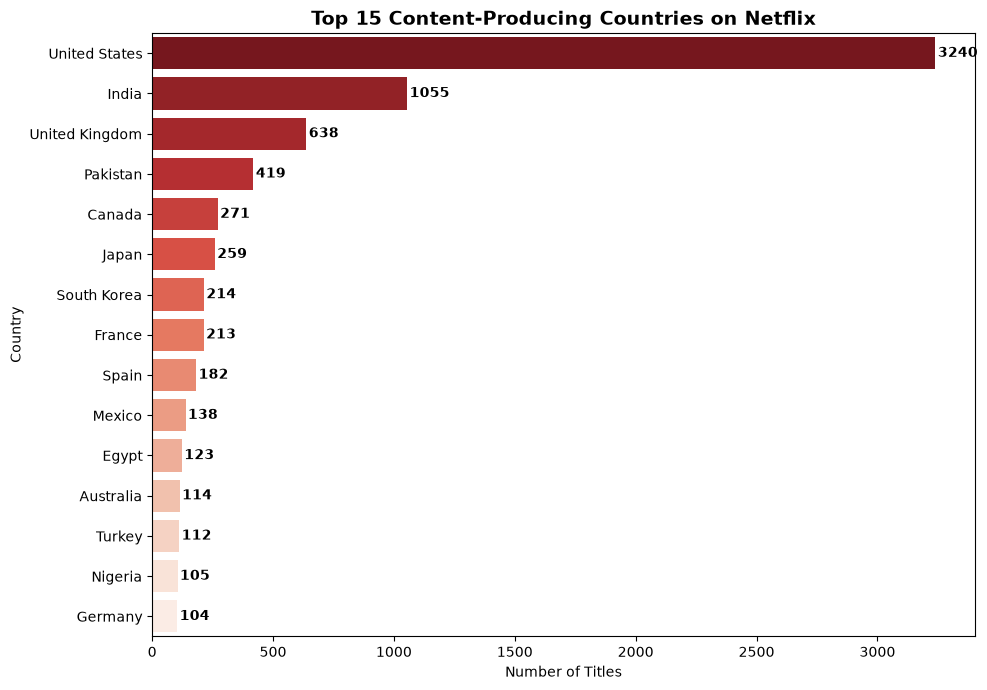

In [5]:
# Configuration for horizontal Bar Chart

plt.figure(figsize = (10, 7))
sbn.barplot (x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='Reds_r', legend=False)

plt.title('Top 15 Content-Producing Countries on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

for i, v in enumerate(top_countries.values):
    plt.text(v + 10, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/Task3_01.top15_countries.png', dpi=300, bbox_inches='tight')
plt.show()

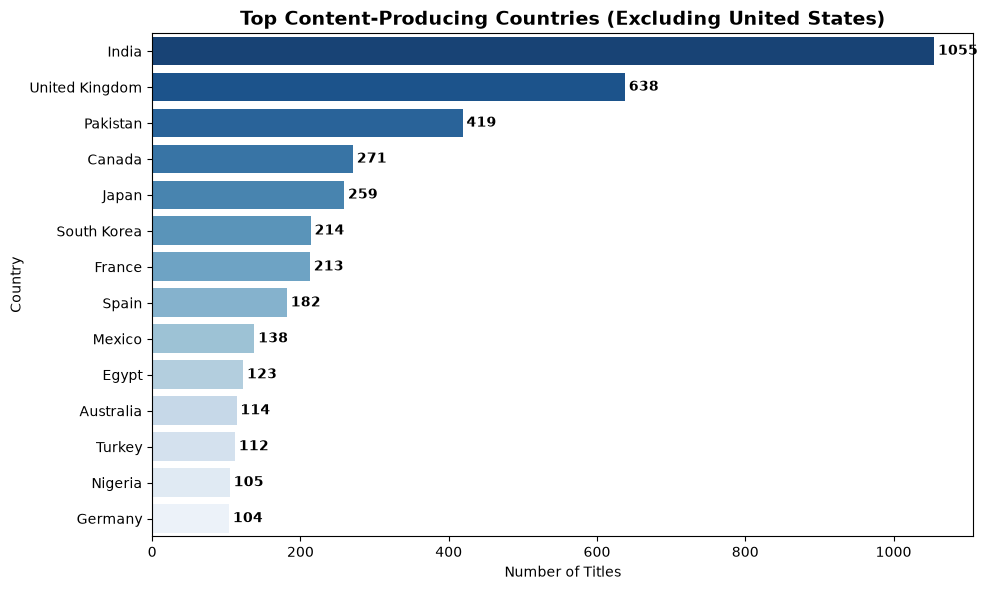

In [6]:
# Configuration for removing outlier(US) from the list

top_countries_noUS = top_countries.drop('United States')  # Excluding Outlier

plt.figure(figsize=(10, 6))
sbn.barplot(x=top_countries_noUS.values, y=top_countries_noUS.index,
            hue=top_countries_noUS.index, palette='Blues_r', legend=False)
plt.title('Top Content-Producing Countries (Excluding United States)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

for i, v in enumerate(top_countries_noUS.values):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/Task3_02.top_countries_excl_us.png', dpi=300, bbox_inches='tight')
plt.show()

BREAKDOWN OF COUNTRY-WISE CONTENT BASED ON ITS TYPE(MOVIE, TV SHOW):

In [7]:
# Movie vs TV Show breakdown for the top 10 countries, using groupby
top_10_names = top_countries.head(10).index
country_type_breakdown = (
    df[df['country'].isin(top_10_names)]
    .groupby(['country', 'type'])
    .size()
    .unstack()
)
print(country_type_breakdown)

type            Movie  TV Show
country                       
Canada            187       84
France            148       65
India             974       81
Japan              87      172
Mexico             90       48
Pakistan           71      348
South Korea        49      165
Spain             129       53
United Kingdom    387      251
United States    2395      845


In [8]:
# normalizes each country's Movie/TV Show counts into within-country percentages

country_type_percent = country_type_breakdown.div(country_type_breakdown.sum(axis=1), axis=0) * 100 # divides each row by its own row total, so countries are compared fairly regardless of how many total titles they have
print(country_type_percent.round(1))

type            Movie  TV Show
country                       
Canada           69.0     31.0
France           69.5     30.5
India            92.3      7.7
Japan            33.6     66.4
Mexico           65.2     34.8
Pakistan         16.9     83.1
South Korea      22.9     77.1
Spain            70.9     29.1
United Kingdom   60.7     39.3
United States    73.9     26.1


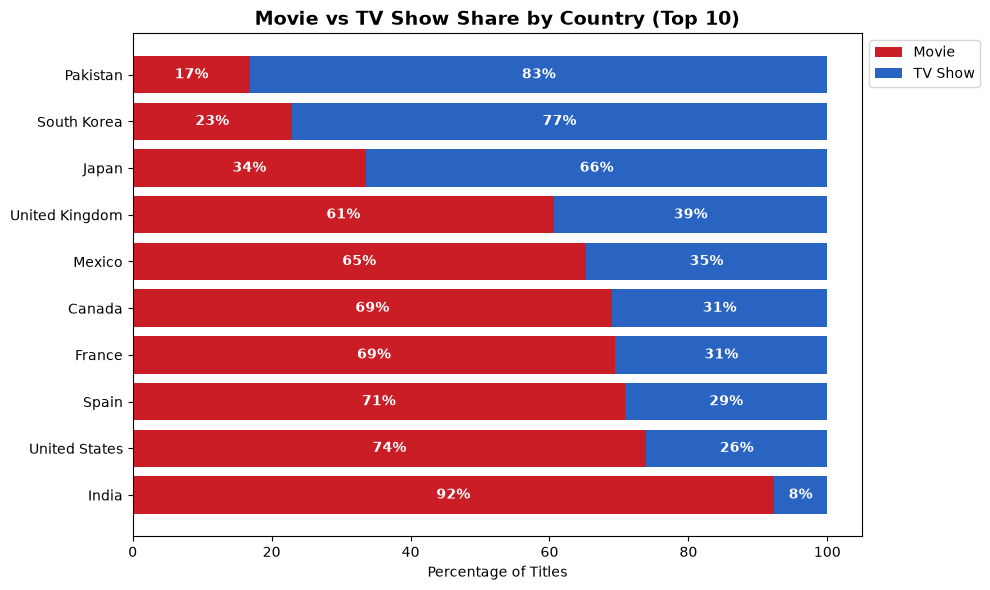

In [9]:
# sort by TV Show % so the chart reads as a gradient from most Movie-heavy to most TV-heavy
sorted_data = country_type_percent.sort_values('TV Show')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sorted_data.index, sorted_data['Movie'], color='#CB1D26', label='Movie')
ax.barh(sorted_data.index, sorted_data['TV Show'], left=sorted_data['Movie'], color='#2a64c2', label='TV Show')

ax.set_title('Movie vs TV Show Share by Country (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage of Titles')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

# label each segment with its percentage
for i, (movie_pct, tv_pct) in enumerate(zip(sorted_data['Movie'], sorted_data['TV Show'])):
    ax.text(movie_pct / 2, i, f'{movie_pct:.0f}%', va='center', ha='center', fontweight='bold', color='white')
    ax.text(movie_pct + tv_pct / 2, i, f'{tv_pct:.0f}%', va='center', ha='center', fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('../screenshots/Task3_03.movie_tv_share_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

-Pakistan, South Korea, Japan invert the platform's overall trend.They are TV Show heavy.

-India is the strongest Movie leaning among the Top 10 countries with 92.3% Movies vs. 7.7% TV Shows.